In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [4]:
def fem_1d_dirichlet(f, a, b, ua, ub, n_elements):
    x = np.linspace(a, b, n_elements + 1)
    n_nodes = len(x)
    # Matriz global de rigidez y vector global de carga
    K = np.zeros((n_nodes, n_nodes), dtype=float)
    F = np.zeros(n_nodes, dtype=float)
    for e in range(n_elements):
        x1 = x[e]
        x2 = x[e + 1]
        h = x2 - x1
        # Matriz de rigidez elemental
        Ke = (1.0 / h) * np.array([[ 1.0, -1.0],[-1.0,  1.0]])
        N1 = lambda xx: (x2 - xx) / h
        N2 = lambda xx: (xx - x1) / h
        # Vector de carga elemental
        Fe = np.array([quad(lambda xx: f(xx) * N1(xx), x1, x2)[0],quad(lambda xx: f(xx) * N2(xx), x1, x2)[0]])
        nodes = [e, e + 1]
        # Ensamblaje
        for i_local, i_global in enumerate(nodes):
            F[i_global] += Fe[i_local]
            for j_local, j_global in enumerate(nodes):
                K[i_global, j_global] += Ke[i_local, j_local]
    K_original = K.copy()
    F_original = F.copy()
    F = F - K[:, 0] * ua - K[:, -1] * ub
    K[0, :] = 0.0
    K[:, 0] = 0.0
    K[0, 0] = 1.0
    K[-1, :] = 0.0
    K[:, -1] = 0.0
    K[-1, -1] = 1.0
    F[0] = ua
    F[-1] = ub
    # Resolver el sistema lineal
    U = np.linalg.solve(K, F)
    return x, U, K_original, F_original

**Ejercicio 1**


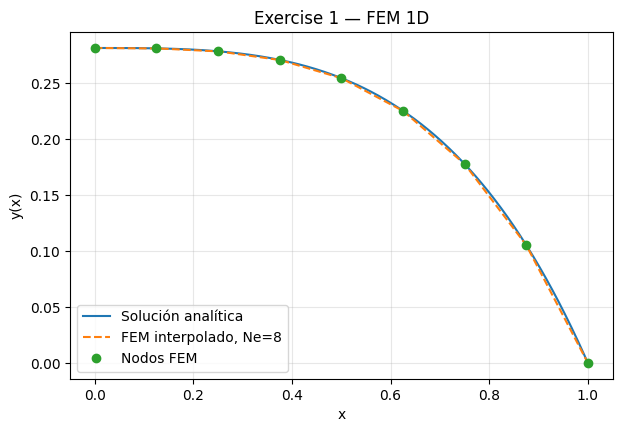

In [9]:
#Solución de la EDO
def f1(x):
    return x * np.exp(x)
def exact1(x):
    return 1.0 - np.e - np.exp(x) * (x - 2.0) - x
Ne = 8
x1, y1, K1, F1 = fem_1d_dirichlet(f=f1,a=0.0,b=1.0,ua=3.0 - np.e,ub=0.0,n_elements=Ne)
xfine = np.linspace(0.0, 1.0, 1000)
y1_interp = np.interp(xfine, x1, y1)
plt.figure(figsize=(7, 4.5))
plt.plot(xfine, exact1(xfine), label="Solución analítica")
plt.plot(xfine, y1_interp, "--", label=f"FEM interpolado, Ne={Ne}")
plt.plot(x1, y1, "o", label="Nodos FEM")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Exercise 1 — FEM 1D")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [8]:
#Comparación para algunos numeros de elementos finitos
for Ne in [4, 8, 16, 32]:
    x, y, _, _ = fem_1d_dirichlet(f=f1,a=0.0,b=1.0,ua=3.0 - np.e,ub=0.0,n_elements=Ne)
    xfine = np.linspace(0.0, 1.0, 5000)
    y_fem = np.interp(xfine, x, y)
    error = np.max(np.abs(y_fem - exact1(xfine)))
    print(f"Ne = {Ne:2d} | error máximo ≈ {error:.6e}")

Ne =  4 | error máximo ≈ 1.650144e-02
Ne =  8 | error máximo ≈ 4.682695e-03
Ne = 16 | error máximo ≈ 1.246689e-03
Ne = 32 | error máximo ≈ 3.215967e-04


**Ejercicio 2**

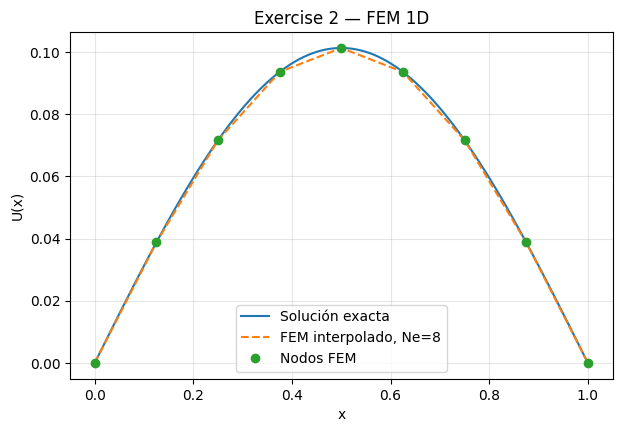

In [10]:
#Slc
def f2(x):
    return np.sin(np.pi * x)
def exact2(x):
    return np.sin(np.pi * x) / np.pi**2
Ne = 8
x2, u2, K2, F2 = fem_1d_dirichlet(f=f2,a=0.0,b=1.0,ua=0.0,ub=0.0,n_elements=Ne)
xfine = np.linspace(0.0, 1.0, 1000)
u2_interp = np.interp(xfine, x2, u2)
plt.figure(figsize=(7, 4.5))
plt.plot(xfine, exact2(xfine), label="Solución exacta")
plt.plot(xfine, u2_interp, "--", label=f"FEM interpolado, Ne={Ne}")
plt.plot(x2, u2, "o", label="Nodos FEM")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.title("Exercise 2 — FEM 1D")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [11]:
#Comparación
for Ne in [4, 8, 16, 32]:
    x, u, _, _ = fem_1d_dirichlet(f=f2,a=0.0,b=1.0,ua=0.0,ub=0.0,n_elements=Ne)
    xfine = np.linspace(0.0, 1.0, 5000)
    u_fem = np.interp(xfine, x, u)
    error = np.max(np.abs(u_fem - exact2(xfine)))
    print(f"Ne = {Ne:2d} | error máximo ≈ {error:.6e}")

Ne =  4 | error máximo ≈ 7.130741e-03
Ne =  8 | error máximo ≈ 1.909530e-03
Ne = 16 | error máximo ≈ 4.855368e-04
Ne = 32 | error máximo ≈ 1.218953e-04
